In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('houses.csv')
print(df.head())
print(df.shape)
print(df.isnull().sum())

   size_sqft  bedrooms  age_years  price_$k
0        800         2         30       150
1       1100         2         25       195
2       1300         3         20       210
3       1500         3         15       260
4       1700         3         12       295
(10, 4)
size_sqft    0
bedrooms     0
age_years    0
price_$k     0
dtype: int64


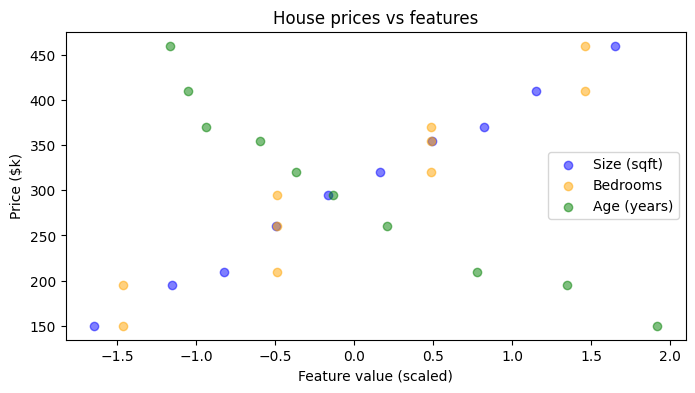

In [67]:
x = df[['size_sqft', 'bedrooms', 'age_years']].values
y = df['price_$k'].values
X_mean = np.mean(x, axis=0)
X_std = np.std(x, axis=0)
X_scaled = (x - X_mean) / X_std
y_mean = np.mean(y)
y_std = np.std(y)
y_scaled = (y - y_mean) / y_std
plt.figure(figsize=(8, 4))
plt.scatter(X_scaled[:, 0], y, color='blue', label='Size (sqft)', alpha=0.5)
plt.scatter(X_scaled[:, 1], y, color='orange', label='Bedrooms', alpha=0.5)
plt.scatter(X_scaled[:, 2], y, color='green', label='Age (years)', alpha=0.5)
plt.xlabel('Feature value (scaled)')
plt.ylabel('Price ($k)')
plt.title('House prices vs features')
plt.legend()
plt.show()



In [ ]:
def predict(X, w, b):
    return np.dot(X, w) + b

def mse(y_true,y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true,y_pred):
    return np.abs(y_true - y_pred).mean() 

def compute_gradient(X, y, w, b):
    y_pred = predict(X, w, b)
    error = y - y_pred
    dw = np.mean(-2 * X * error.reshape(-1, 1), axis=0)
    db = np.mean(-2 * error)
    return dw, db




In [69]:
w = np.zeros(3)
b = 0.0
learning_rate = 0.01
epochs = 200
loss_history = []

for epoch in range(epochs):
    predictions = predict(X_scaled, w, b)
    dw, db = compute_gradient(X_scaled, y_scaled, w, b)
    w -= learning_rate * dw
    b -= learning_rate * db
    current_mse = mse(y_scaled, predictions)
    loss_history.append(current_mse)
    if epoch % 20 == 0:
     print(f"Epoch {epoch} → w={np.round(w,4)} b={b:.4f} MSE={current_mse:.1f}")

Epoch 0 → w=[ 0.0199  0.0192 -0.0194] b=-0.0000 MSE=1.0
Epoch 20 → w=[ 0.2479  0.2336 -0.2375] b=0.0000 MSE=0.1
Epoch 40 → w=[ 0.3208  0.2947 -0.3021] b=0.0000 MSE=0.0
Epoch 60 → w=[ 0.347   0.3099 -0.3205] b=0.0000 MSE=0.0
Epoch 80 → w=[ 0.3591  0.3112 -0.3249] b=0.0000 MSE=0.0
Epoch 100 → w=[ 0.3669  0.3085 -0.3252] b=0.0000 MSE=0.0
Epoch 120 → w=[ 0.3734  0.3046 -0.3242] b=0.0000 MSE=0.0
Epoch 140 → w=[ 0.3795  0.3003 -0.3228] b=0.0000 MSE=0.0
Epoch 160 → w=[ 0.3854  0.296  -0.3212] b=0.0000 MSE=0.0
Epoch 180 → w=[ 0.3912  0.2918 -0.3197] b=0.0000 MSE=0.0


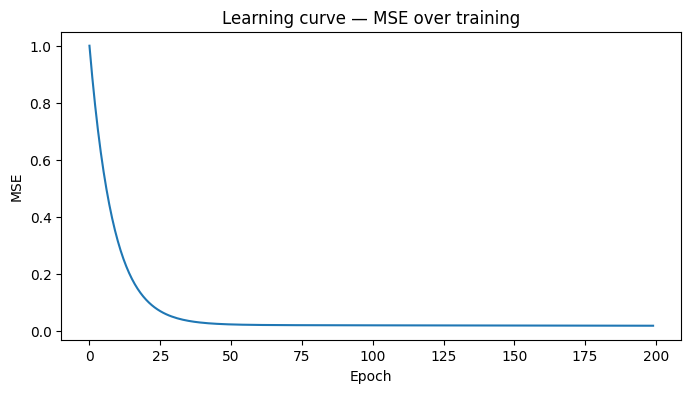

In [70]:
plt.figure(figsize=(8, 4))
plt.plot(range(epochs), loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Learning curve — MSE over training')
plt.show()